In [4]:
import pandas as pd

# Load summary CSVs
df_both = pd.read_csv(r'Parameters Comparison Summary\summary_results.csv')
df_same = pd.read_csv(r'Parameters Comparison Summary\summary_results_entry_on_either_two_candles.csv')

# Add a tag column to distinguish the sources
df_both['Entry_Type'] = 'Same_Candle'
df_same['Entry_Type'] = 'Both_Candle'

# Combine both into one DataFrame
df_combined = pd.concat([df_both, df_same], ignore_index=True)


In [7]:
# Pivot by metric for easy visual comparison
pivot = df_combined.pivot_table(
    index=['Window', 'SL Multiplier'],
    columns='Entry_Type',
    values='Total PnL'  # 🔁 change this to any metric you want
).reset_index()
pivot['PnL_Diff'] = pivot['Both_Candle'] - pivot['Same_Candle']
pivot['PnL_%_Improvement'] = (pivot['PnL_Diff'] / pivot['Same_Candle']) * 100


print(pivot.head())
print(pivot.sort_values())

Entry_Type  Window  SL Multiplier  Both_Candle  Same_Candle  PnL_Diff  \
0                1           1.00    9983.5800    7284.9200  2698.660   
1                1           1.50   10053.1350    7397.1000  2656.035   
2                1           2.00   10029.8100    7314.7000  2715.110   
3                1           2.50    9899.0750    7253.4100  2645.665   
4                1           2.75    9838.8875    7299.2175  2539.670   

Entry_Type  PnL_%_Improvement  
0                   37.044470  
1                   35.906436  
2                   37.118542  
3                   36.474775  
4                   34.793730  


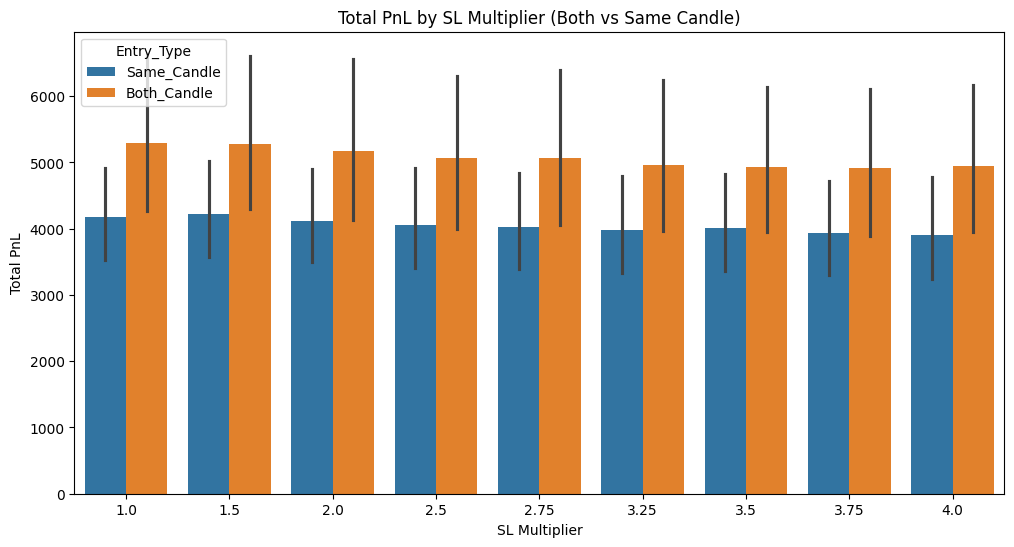

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_combined,
    x='SL Multiplier', y='Total PnL',
    hue='Entry_Type'
)
plt.title("Total PnL by SL Multiplier (Both vs Same Candle)")
plt.show()


In [9]:
print(pivot.sort_values('PnL_%_Improvement', ascending=False))


Entry_Type  Window  SL Multiplier  Both_Candle  Same_Candle   PnL_Diff  \
25               3           3.75     5539.240    3672.7025  1866.5375   
22               3           2.75     5582.475    3749.5200  1832.9550   
26               3           4.00     5456.030    3677.6300  1778.4000   
23               3           3.25     5498.890    3708.3900  1790.5000   
18               3           1.00     5882.320    3967.3600  1914.9600   
..             ...            ...          ...          ...        ...   
57               7           2.50     3880.005    3655.3550   224.6500   
56               7           2.00     3934.070    3715.8500   218.2200   
55               7           1.50     4094.920    3897.9800   196.9400   
65               8           2.00     3495.080    3332.9500   162.1300   
66               8           2.50     3432.260    3296.3050   135.9550   

Entry_Type  PnL_%_Improvement  
25                  50.821908  
22                  48.885057  
26             

In [10]:
len(pivot)


90